<a href="https://colab.research.google.com/github/Tahsina2226/spam_email_ml/blob/main/prl_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ipywidgets matplotlib seaborn plotly wordcloud scikit-learn nltk joblib --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.7 MB/s eta 0:00:00


In [ ]:
import os, re, warnings
warnings.filterwarnings("ignore")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

colors = ['#96A78D', '#B6CEB4', '#D9E9CF']
sns.set_palette(colors)
sns.set_style("whitegrid")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
DATA_PATH = "/content/spam_ham_dataset.csv"
raw_df = pd.read_csv(DATA_PATH, encoding='latin-1', low_memory=False)
df = raw_df[['label','text']].rename(columns={'text':'message'}).dropna().reset_index(drop=True)


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+',' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if t not in stop_words and len(t)>1]
    return " ".join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
df['msg_length'] = df['message'].apply(lambda x: len(str(x)))
df['word_count'] = df['clean_message'].apply(lambda x: len(x.split()))


In [ ]:
label_counts = df['label'].value_counts()
labels_to_keep = label_counts[label_counts > 1].index
df = df[df['label'].isin(labels_to_keep)]

ham_df = df[df['label']=='ham']
spam_df = df[df['label']=='spam']
if len(ham_df) < len(spam_df):
    spam_df = spam_df.sample(len(ham_df), random_state=42)
df = pd.concat([ham_df, spam_df]).sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
X = df['clean_message']; y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
vectorizer = TfidfVectorizer(max_features=6000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
nb_model = MultinomialNB(); nb_model.fit(X_train_vec, y_train)
lr_model = LogisticRegression(class_weight='balanced', max_iter=300); lr_model.fit(X_train_vec, y_train)
nn_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300); nn_model.fit(X_train_vec, y_train)

models = {'Naive Bayes': nb_model, 'Logistic Regression': lr_model, 'Neural Network': nn_model}


In [ ]:
def evaluate_model(model, X_t, y_t, name):
    y_pred = model.predict(X_t)
    acc = accuracy_score(y_t, y_pred)
    prec = precision_score(y_t, y_pred, pos_label='spam')
    rec = recall_score(y_t, y_pred, pos_label='spam')
    f1 = f1_score(y_t, y_pred, pos_label='spam')
    cm = confusion_matrix(y_t, y_pred, labels=['ham','spam'])
    return {'name':name, 'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1, 'confusion_matrix':cm}

results = {name: evaluate_model(model, X_test_vec, y_test, name) for name, model in models.items()}
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = models[best_model_name]
os.makedirs("saved_models", exist_ok=True)
joblib.dump(best_model, "saved_models/best_spam_model.joblib")
joblib.dump(vectorizer, "saved_models/tfidf_vectorizer.joblib")


['saved_models/tfidf_vectorizer.joblib']

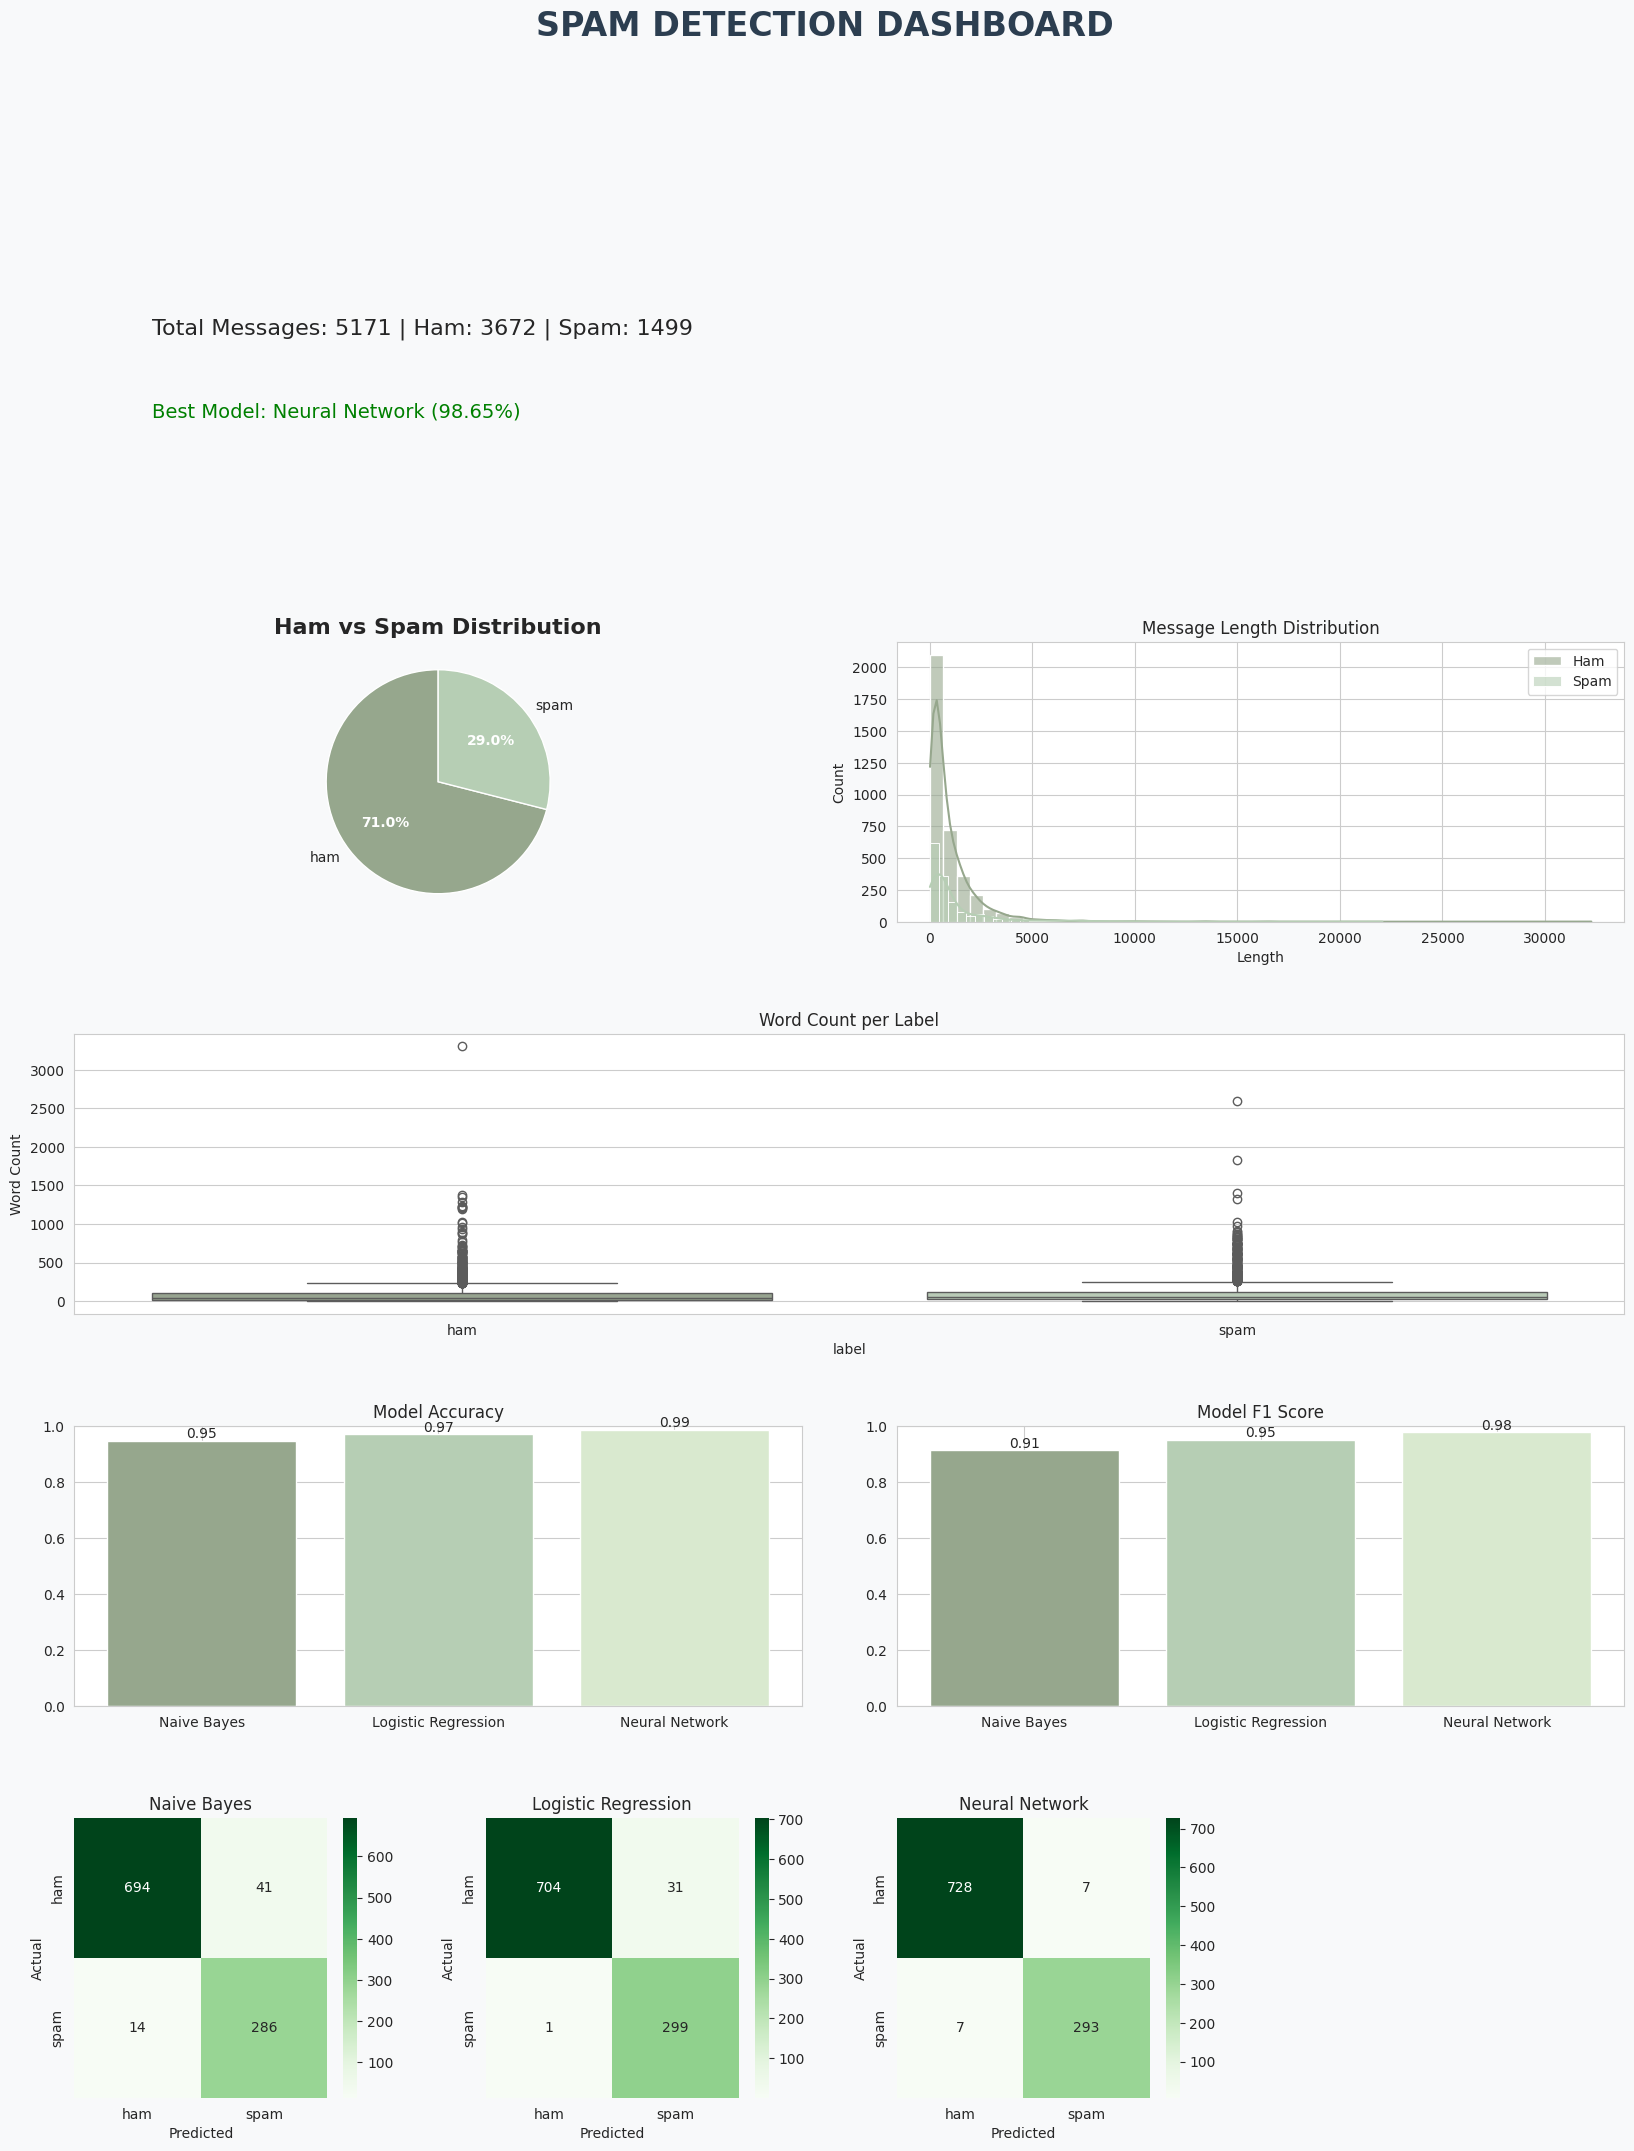

In [ ]:
def create_dashboard(df, results):
    fig = plt.figure(figsize=(20,24), facecolor='#f8f9fa')
    fig.suptitle('SPAM DETECTION DASHBOARD', fontsize=24, fontweight='bold', color='#2c3e50')
    gs = GridSpec(5,4, figure=fig, hspace=0.4, wspace=0.3)

    ax_header = fig.add_subplot(gs[0,:]); ax_header.axis('off')
    total, ham_count, spam_count = len(df), len(df[df['label']=='ham']), len(df[df['label']=='spam'])
    ax_header.text(0.05,0.7, f"Total Messages: {total} | Ham: {ham_count} | Spam: {spam_count}", fontsize=16)
    ax_header.text(0.05,0.4, f"Best Model: {best_model_name} ({results[best_model_name]['accuracy']*100:.2f}%)", fontsize=14, color='green')

    ax1 = fig.add_subplot(gs[1,0:2])
    counts = df['label'].value_counts()
    wedges, _, autotexts = ax1.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
    for autotext in autotexts: autotext.set_color('white'); autotext.set_fontweight('bold')
    ax1.set_title("Ham vs Spam Distribution", fontsize=16, fontweight='bold')

    ax2 = fig.add_subplot(gs[1,2:])
    sns.histplot(df[df['label']=='ham']['msg_length'], bins=50, color=colors[0], label='Ham', kde=True, alpha=0.6, ax=ax2)
    sns.histplot(df[df['label']=='spam']['msg_length'], bins=50, color=colors[1], label='Spam', kde=True, alpha=0.6, ax=ax2)
    ax2.set_title("Message Length Distribution"); ax2.set_xlabel("Length"); ax2.set_ylabel("Count"); ax2.legend()

    ax3 = fig.add_subplot(gs[2,:])
    sns.boxplot(x='label', y='word_count', data=df, palette=colors, ax=ax3)
    ax3.set_title("Word Count per Label"); ax3.set_ylabel("Word Count")

    model_names = list(results.keys())
    accuracies = [results[m]['accuracy'] for m in model_names]
    f1_scores = [results[m]['f1'] for m in model_names]

    ax4 = fig.add_subplot(gs[3,:2])
    bars = ax4.bar(model_names, accuracies, color=colors+[colors[0]])
    ax4.set_title("Model Accuracy"); ax4.set_ylim(0,1)
    for bar in bars: ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.2f}", ha='center')

    ax5 = fig.add_subplot(gs[3,2:])
    bars = ax5.bar(model_names, f1_scores, color=colors+[colors[1]])
    ax5.set_title("Model F1 Score"); ax5.set_ylim(0,1)
    for bar in bars: ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"{bar.get_height():.2f}", ha='center')

    for i, m in enumerate(model_names):
        ax = fig.add_subplot(gs[4,i])
        sns.heatmap(results[m]['confusion_matrix'], annot=True, fmt='d', cmap='Greens', xticklabels=['ham','spam'], yticklabels=['ham','spam'], ax=ax)
        ax.set_title(m); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

    plt.tight_layout(rect=[0,0.03,1,0.97])
    plt.show()

create_dashboard(df, results)


In [ ]:
def predict_message(msg, model=best_model, vect=vectorizer):
    if len(msg.split()) < 3:
        return 'ham', [0.99,0.01]
    cleaned = clean_text(msg)
    vec = vect.transform([cleaned])
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    return pred, prob


In [ ]:
message_input = widgets.Textarea(value='Congratulations! You won a car!', placeholder='Type your message...', layout=widgets.Layout(width='90%', height='100px'))
test_button = widgets.Button(description='Test Message', button_style='success')
result_output = widgets.Output()

def on_test(b):
    with result_output:
        clear_output()
        msg = message_input.value
        if not msg.strip(): print("Enter a message to test."); return
        pred, prob = predict_message(msg)
        conf = max(prob)*100
        status = "✅ HAM" if pred=='ham' else "🚫 SPAM"
        print(f"Message: {msg}\nResult: {status}\nConfidence: {conf:.2f}%")
        print(f"Ham: {prob[0]*100:.2f}%, Spam: {prob[1]*100:.2f}%")
test_button.on_click(on_test)
display(message_input); display(test_button); display(result_output)


Textarea(value='Congratulations! You won a car!', layout=Layout(height='100px', width='90%'), placeholder='Typ…

Button(button_style='success', description='Test Message', style=ButtonStyle())

Output()

In [ ]:
examples = [
    "Congratulations! You won a car.",
    "Hey bro, are you coming?",
    "Urgent: Reset your password now!",
    "Your package has been delivered.",
    "Free trial! Get premium account now!"
]
print("\nTry these examples or type your own message above:\n")
for i, ex in enumerate(examples,1): print(f"{i}. {ex}")



Try these examples or type your own message above:

1. Congratulations! You won a car.
2. Hey bro, are you coming?
3. Urgent: Reset your password now!
4. Your package has been delivered.
5. Free trial! Get premium account now!
